In [1]:
import reskit as rk
import pandas as pd
import numpy as np

This script illustrates how to run a simulation with ETHOS.RESKit.CoolingHeating.


In [2]:
# Create Placements DataFrame with turbine locations and specifications

placements = pd.DataFrame(
    {
        "lon": [5.5, 5.994685, 6.8],
        "lat": [50.797254, 50.794208, 49.5],
        "capacity": [4000, 4000, 4000],
    }
)
placements

,lon,lat,capacity
0,5.500000,50.797254,4000
1,5.994685,50.794208,4000
2,6.800000,49.500000,4000


# Run the simulation workflow
RESKit will run the simulation and create an xarray Dataset with the simulation results for you.
Apart from the capacity_factor, RESKit also includes the turbine specifications and intermediate data used to determine the capacity factor (such as wind speeds, surface pressure etc.)

In [3]:
reskit_xr = rk.cooling_heating.air_cooling_wenzel2025(
    placements=placements,
    era5_path=rk.TEST_DATA["era5-like"],
    temperatureCoolant=40,
    designTemperature=20
)
reskit_xr

<xarray.Dataset> Size: 31kB
Dimensions:                             (location: 3, time: 140)
Coordinates:
  * location                            (location) int64 24B 0 1 2
  * time                                (time) datetime64[ns] 1kB 2014-12-31T...
Data variables:
    lon                                 (location) float64 24B 5.5 5.995 6.8
    lat                                 (location) float64 24B 50.8 50.79 49.5
    capacity                            (location) int64 24B 4000 4000 4000
    surface_air_temperature             (time, location) float64 3kB -0.248 ....
    conversion_factor_fan_electricity   (time, location) float64 3kB -0.00813...
    conversion_factor_pump_electricity  (time, location) float64 3kB -0.00194...
    capacity_factor                     (time, location) float64 3kB 1.145 .....
    conversion_factor_electricity       (time, location) float64 3kB -0.01008...
    cooling_output                      (time, location) float64 3kB 4.58e+03...
    electricity_input                   (time, location) float64 3kB 46.16 .....
    electricity_input_fan               (time, location) float64 3kB 37.27 .....
    electricity_input_pump              (time, location) float64 3kB 8.889 .....

RESKit will output the capacity factor of each location for every hour of the simulated year.

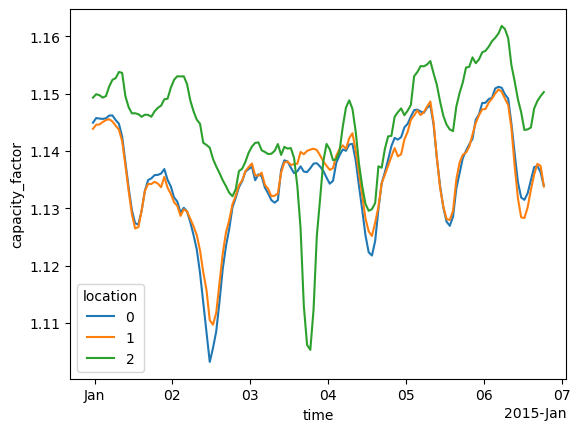

In [4]:
reskit_xr["capacity_factor"].isel(time=slice(0, 400)).plot.line(x="time")

As well as the conversion factors:

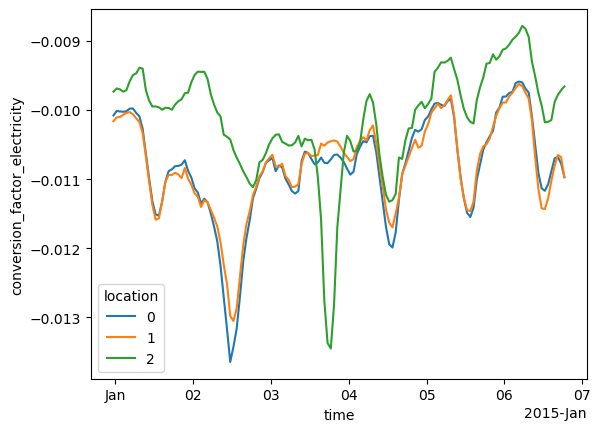

In [5]:
reskit_xr["conversion_factor_electricity"].isel(time=slice(0, 400)).plot.line(x="time")

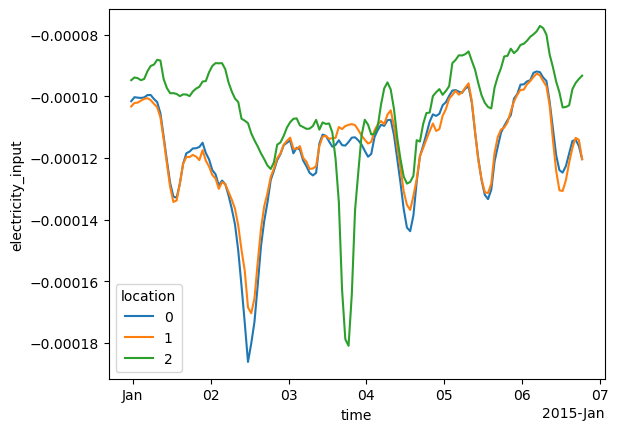

In [6]:
reskit_xr["electricity_input"].isel(time=slice(0, 400)).plot.line(x="time")